# LU Decomposition (Doolittle Method)
> **Numerical Methods for Engineering** | Module 02 - Linear Systems | `02_LU_Decomposition.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/02-Linear-Systems/02_LU_Decomposition.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- Explain the **LU factorisation** of a matrix as a structured alternative to Gaussian elimination.
- Apply the **Doolittle algorithm** to compute lower ($L$) and upper ($U$) triangular factors.
- Incorporate **partial pivoting** via a permutation matrix $P$ so that $PA = LU$.
- Solve $A\mathbf{x} = \mathbf{b}$ in two cheap $\mathcal{O}(n^2)$ substitution steps once $L$, $U$, $P$ are known.
- Exploit the factorisation to handle **multiple right-hand sides** at $\mathcal{O}(n^2)$ marginal cost.
- Apply the method to matrix inversion, heat-conduction parameter studies, and antenna array design.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(11,5),'font.size':12,
    'axes.grid':True,'grid.alpha':0.35,'lines.linewidth':2})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 Motivation: Reusing Work for Multiple Right-Hand Sides

Gaussian elimination solves $A\mathbf{x} = \mathbf{b}$ in $\mathcal{O}(n^3/3)$ operations.
If we need to solve the same system for $k$ different vectors $\mathbf{b}_1, \ldots, \mathbf{b}_k$,
repeating Gaussian elimination costs $k \times \mathcal{O}(n^3/3)$ — wasteful, since $A$ is the
same each time.

**LU decomposition** separates the expensive factorisation ($\mathcal{O}(n^3/3)$, done once)
from the cheap substitution ($\mathcal{O}(n^2)$, repeated per right-hand side):

$$\underbrace{A = LU}_{\mathcal{O}(n^3/3)}
\quad\Longrightarrow\quad
\underbrace{L\mathbf{y} = \mathbf{b}}_{\mathcal{O}(n^2)}
\;\text{then}\;
\underbrace{U\mathbf{x} = \mathbf{y}}_{\mathcal{O}(n^2)}$$

---

### 1.2 Doolittle Factorisation

The **Doolittle method** imposes a unit lower triangular $L$ ($l_{ii}=1$) and a free upper
triangular $U$. Matching $A = LU$ entry by entry gives the recurrences:

**Upper triangular entries** (row $k$, columns $j \geq k$):

$$u_{kj} = a_{kj} - \sum_{s=0}^{k-1} l_{ks}\,u_{sj}$$

**Lower triangular entries** (column $k$, rows $i > k$):

$$l_{ik} = \frac{1}{u_{kk}}\left(a_{ik} - \sum_{s=0}^{k-1} l_{is}\,u_{sk}\right)$$

---

### 1.3 Partial Pivoting — $PA = LU$

Without pivoting, a zero or tiny $u_{kk}$ makes $l_{ik}$ undefined or huge.
**Partial pivoting** uses a **permutation matrix** $P$ that records row swaps:

$$P A = L U$$

The solution procedure becomes:
1. Factorise: $PA = LU$ (once, $\mathcal{O}(n^3/3)$)
2. Permute: $\mathbf{b}' = P\mathbf{b}$
3. Forward substitution: $L\mathbf{y} = \mathbf{b}'$
4. Back substitution: $U\mathbf{x} = \mathbf{y}$

---

### 1.4 Forward and Back Substitution

Given unit lower triangular $L$ and $\mathbf{b}' = P\mathbf{b}$:

$$y_i = b'_i - \sum_{j=0}^{i-1} l_{ij}\,y_j, \qquad i = 0, 1, \ldots, n-1$$

Given upper triangular $U$:

$$x_i = \frac{y_i - \displaystyle\sum_{j=i+1}^{n-1} u_{ij}\,x_j}{u_{ii}},
\qquad i = n-1, \ldots, 0$$

Each substitution costs exactly $n^2/2$ multiplications.

---

### 1.5 Matrix Inversion via LU

To compute $A^{-1}$, solve $A X = I$ for $X$. Each column of $I$ is a right-hand side $\mathbf{e}_k$,
so $n$ solves are needed. With LU, each costs only $\mathcal{O}(n^2)$:

$$A^{-1}_{\text{column } k} = \text{lu\_solve}(L, U, P, \mathbf{e}_k)$$

Total cost: $\mathcal{O}(n^3/3) + n \times \mathcal{O}(n^2) = \mathcal{O}(n^3)$.

---

### 1.6 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| **Multiple RHS** at $\mathcal{O}(n^2)$ marginal cost | $\mathcal{O}(n^3)$ initial factorisation — same as GE |
| Efficient **matrix inversion** and **determinant** ($\det A = \prod u_{ii}$) | Dense $L$ and $U$ stored simultaneously — $2n^2$ memory |
| Sparse storage possible for banded/structured matrices | Not suitable for large sparse systems (use iterative methods) |
| Factorisation can be **updated** cheaply for rank-1 changes | LU is not unique without the unit diagonal convention |


In [2]:
def lu_decompose(A):
    # Doolittle LU decomposition with partial pivoting: returns L, U, P such that P@A = L@U
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()
    P = np.eye(n)
    for k in range(n - 1):
        # Partial pivoting: find row with largest |U[k:, k]|
        p = k + int(np.argmax(np.abs(U[k:, k])))
        if p != k:
            U[[k, p]]      = U[[p, k]]
            P[[k, p]]      = P[[p, k]]
            if k > 0:
                L[[k, p], :k] = L[[p, k], :k]
        if abs(U[k, k]) < 1e-14:
            raise ValueError(f'Singular matrix: zero pivot at column {k}')
        for i in range(k + 1, n):
            L[i, k]  = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
    return L, U, P


def lu_solve(L, U, P, b):
    # Solve A x = b given PA = LU decomposition.  O(n^2) per call.
    b = np.array(b, dtype=float)
    n = len(b)
    pb = P @ b
    # Forward substitution: L y = Pb  (L is unit lower triangular)
    y = np.zeros(n)
    for i in range(n):
        y[i] = pb[i] - L[i, :i] @ y[:i]
    # Back substitution: U x = y
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x


def lu_invert(A):
    # Invert A by solving A X = I column by column.
    n = A.shape[0]
    L, U, P = lu_decompose(A)
    Ainv = np.zeros((n, n))
    for k in range(n):
        e_k = np.zeros(n); e_k[k] = 1.0
        Ainv[:, k] = lu_solve(L, U, P, e_k)
    return Ainv

print('lu_decompose(), lu_solve(), lu_invert() defined.')

lu_decompose(), lu_solve(), lu_invert() defined.


---
## 2. Examples

### 2.1 General Mathematical Example — Factorisation Inspection and Matrix Inversion

We decompose the same $4 \times 4$ Laplacian matrix from Notebook 01 and explicitly display
the factors $L$, $U$, and $P$. We then invert the matrix and verify $A A^{-1} = I$.

**Key insight:** comparing $PA$ with $LU$ entry by entry provides a transparent check that
the factorisation is exact (up to machine precision).


Permutation matrix P:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]

Lower triangular L (unit diagonal):
[[ 1.        0.        0.        0.      ]
 [-0.25      1.        0.        0.      ]
 [ 0.       -0.266667  1.        0.      ]
 [-0.25     -0.066667 -0.285714  1.      ]]

Upper triangular U:
[[ 4.       -1.        0.       -1.      ]
 [ 0.        3.75     -1.       -0.25    ]
 [ 0.        0.        3.733333 -1.066667]
 [ 0.        0.        0.        3.428571]]

Max |PA - LU| = 3.47e-18  (should be ~0)

det(A) via LU  = 192.00000000
det(A) via NP  = 192.00000000

Max |A * A_inv - I| = 2.22e-16  (should be ~0)

A^-1 (rounded):
[[0.291667 0.083333 0.041667 0.083333]
 [0.083333 0.291667 0.083333 0.041667]
 [0.041667 0.083333 0.291667 0.083333]
 [0.083333 0.041667 0.083333 0.291667]]


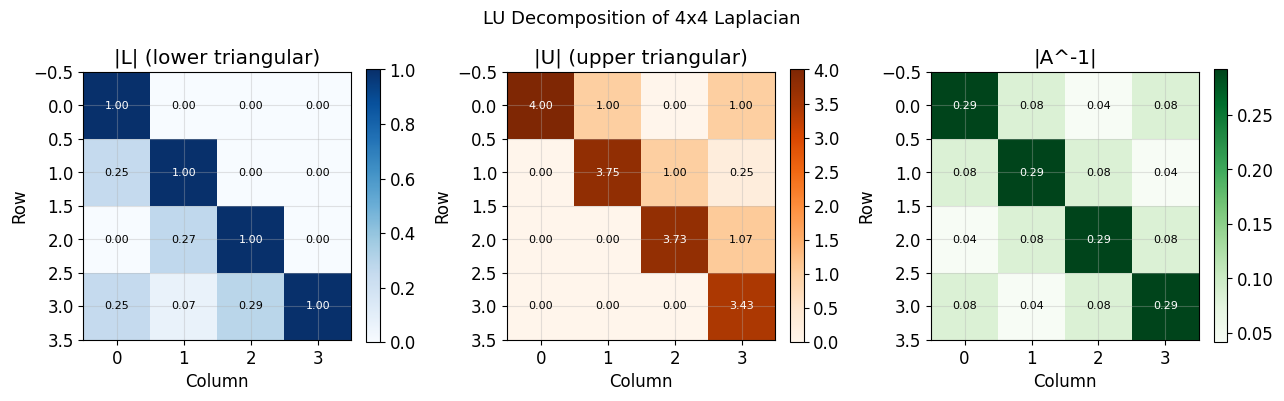

In [3]:
A4 = np.array([[ 4., -1.,  0., -1.],
               [-1.,  4., -1.,  0.],
               [ 0., -1.,  4., -1.],
               [-1.,  0., -1.,  4.]])

L, U, P = lu_decompose(A4)

print('Permutation matrix P:')
print(P.astype(int))
print()
print('Lower triangular L (unit diagonal):')
print(np.round(L, 6))
print()
print('Upper triangular U:')
print(np.round(U, 6))
print()

# Verify PA = LU
err_fact = np.max(np.abs(P @ A4 - L @ U))
print(f'Max |PA - LU| = {err_fact:.2e}  (should be ~0)')
print()

# Determinant from U diagonal
det_lu = np.prod(np.diag(U)) * int(round(np.linalg.det(P)))
det_np = np.linalg.det(A4)
print(f'det(A) via LU  = {det_lu:.8f}')
print(f'det(A) via NP  = {det_np:.8f}')
print()

# Matrix inversion
A4_inv = lu_invert(A4)
err_inv = np.max(np.abs(A4 @ A4_inv - np.eye(4)))
print(f'Max |A * A_inv - I| = {err_inv:.2e}  (should be ~0)')
print()
print('A^-1 (rounded):')
print(np.round(A4_inv, 6))

# Visualisation: spy plots of L and U
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, mat, title, cmap in zip(axes,
        [np.abs(L), np.abs(U), np.abs(A4_inv)],
        ['|L| (lower triangular)', '|U| (upper triangular)', '|A^-1|'],
        ['Blues', 'Oranges', 'Greens']):
    im = ax.imshow(mat, cmap=cmap, aspect='equal')
    ax.set_title(title)
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    plt.colorbar(im, ax=ax, fraction=0.046)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if mat[i,j]>mat.max()*0.6 else 'black')

plt.suptitle('LU Decomposition of 4x4 Laplacian', fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Chemistry Application — 1D Heat Conduction in a Reactor Wall (Multiple Load Cases)

**Background:** A tubular reactor wall of thickness $L = 0.1$ m has spatially uniform heat
generation $q''(x)$ (W/m³) from exothermic reactions. The steady-state temperature profile
satisfies:

$$k \frac{d^2 T}{dx^2} + q'' = 0, \qquad T(0) = T_L, \quad T(L) = T_R$$

Discretising with $n_\text{int} = 6$ interior nodes (spacing $h = L/7$) gives the tridiagonal system:

$$\frac{k}{h^2}\begin{bmatrix}
2 & -1 & & \\
-1 & 2 & -1 & \\
& \ddots & \ddots & \ddots \\
& & -1 & 2
\end{bmatrix} \mathbf{T} = \mathbf{b}(q'', T_L, T_R)$$

The **same stiffness matrix** applies to many operating conditions (different $q''$, $T_L$, $T_R$).
LU factorisation lets us solve each case in $\mathcal{O}(n^2)$ after a single $\mathcal{O}(n^3)$
factorisation step.

**Material:** stainless steel wall, $k = 16$ W/(m·K).


Stiffness matrix K (tridiagonal, 6x6):
[[156800. -78400.      0.      0.      0.      0.]
 [-78400. 156800. -78400.      0.      0.      0.]
 [     0. -78400. 156800. -78400.      0.      0.]
 [     0.      0. -78400. 156800. -78400.      0.]
 [     0.      0.      0. -78400. 156800. -78400.]
 [     0.      0.      0.      0. -78400. 156800.]]

LU factorisation done (computed once).
Max |P K - L U| = 0.00e+00

Case                               T_max (K)     T_min (K)      Residual
------------------------------------------------------------------------
Low q, hot left                        535.2         400.0      2.20e-16
Med q, hot left                        686.7         400.0      2.10e-16
High q, hot left                       916.3         400.0      7.01e-16
Med q, symmetric                       629.6         400.0      4.88e-16
Med q, steep gradient                  705.6         300.0      1.86e-16


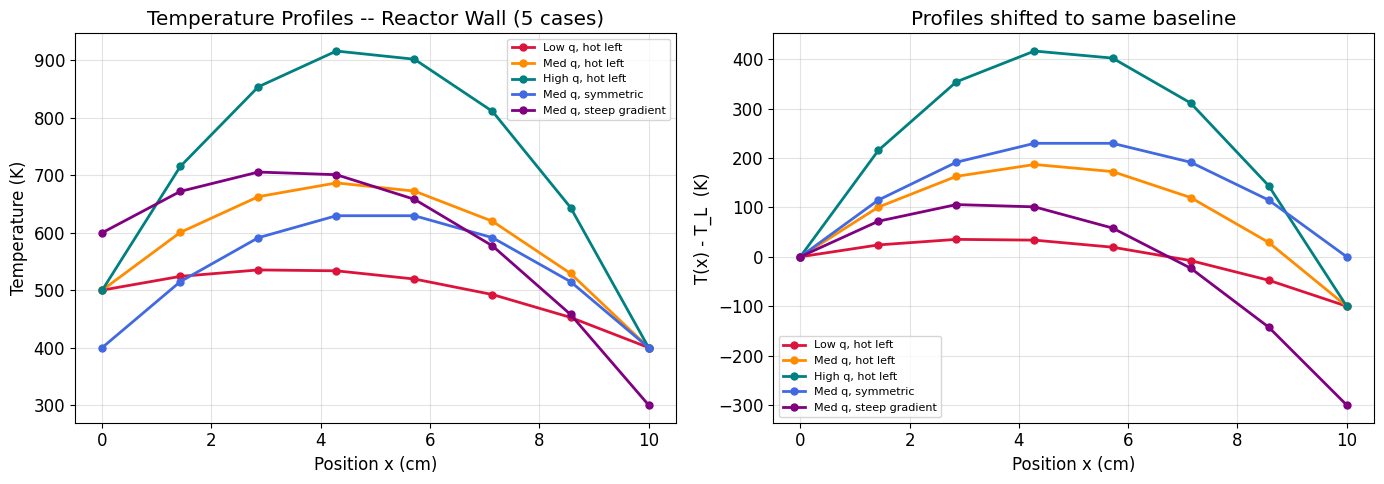

In [4]:
k_cond = 16.0   # W/(m.K)  thermal conductivity
L_wall = 0.10   # m  wall thickness
n_int  = 6      # interior nodes
h      = L_wall / (n_int + 1)   # node spacing

# Tridiagonal stiffness matrix K  (n_int x n_int)
diag  = np.full(n_int,  2.0 * k_cond / h**2)
offdiag = np.full(n_int - 1, -k_cond / h**2)
K = np.diag(diag) + np.diag(offdiag, 1) + np.diag(offdiag, -1)

print('Stiffness matrix K (tridiagonal, 6x6):')
print(np.round(K, 0))
print()

# Factorise ONCE
L_k, U_k, P_k = lu_decompose(K)
print('LU factorisation done (computed once).')
print(f'Max |P K - L U| = {np.max(np.abs(P_k@K - L_k@U_k)):.2e}')
print()

# Define 5 operating cases: (q'' W/m^3, T_L K, T_R K)
cases = [
    (1e6,  500, 400, 'Low q, hot left'),
    (3e6,  500, 400, 'Med q, hot left'),
    (6e6,  500, 400, 'High q, hot left'),
    (3e6,  400, 400, 'Med q, symmetric'),
    (3e6,  600, 300, 'Med q, steep gradient'),
]

x_nodes = np.linspace(0, L_wall, n_int + 2)   # all nodes including boundaries
x_int   = x_nodes[1:-1]                         # interior nodes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes
colors = ['crimson', 'darkorange', 'teal', 'royalblue', 'purple']

print('{:<30}  {:>12}  {:>12}  {:>12}'.format('Case', 'T_max (K)', 'T_min (K)', 'Residual'))
print('-'*72)

for (q, TL, TR, label), col in zip(cases, colors):
    # Build RHS for this case
    b_rhs = np.full(n_int, q)
    b_rhs[0]  += k_cond / h**2 * TL
    b_rhs[-1] += k_cond / h**2 * TR

    # Solve using stored LU -- O(n^2) only
    T_int = lu_solve(L_k, U_k, P_k, b_rhs)
    T_full = np.concatenate([[TL], T_int, [TR]])

    resid = np.max(np.abs(K @ T_int - b_rhs)) / (np.max(np.abs(b_rhs)) + 1e-30)
    print('{:<30}  {:>12.1f}  {:>12.1f}  {:>12.2e}'.format(label, T_full.max(), T_full.min(), resid))

    ax1.plot(x_nodes * 100, T_full, 'o-', color=col, ms=5, lw=2, label=label)
    ax2.plot(x_nodes * 100, T_full - T_full[0], 'o-', color=col, ms=5, lw=2, label=label)

ax1.set(xlabel='Position x (cm)', ylabel='Temperature (K)',
        title='Temperature Profiles -- Reactor Wall (5 cases)')
ax1.legend(fontsize=8)

ax2.set(xlabel='Position x (cm)', ylabel='T(x) - T_L  (K)',
        title='Profiles shifted to same baseline')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.3 Telecommunications Application — Antenna Array Beam Steering

**Background:** In a phased-array antenna, $n$ identical dipole elements are coupled through
mutual impedances. Given an excitation voltage vector $\mathbf{v}$, the element currents
$\mathbf{i}$ satisfy the **impedance-matrix equation** (Pozar, 2012; Balanis, 2016):

$$Z\,\mathbf{i} = \mathbf{v}$$

where $Z_{ij}$ is the mutual impedance between elements $i$ and $j$.

For **beam steering**, we change $\mathbf{v}$ (progressive phase shifts $\psi = kd\cos\theta$)
while $Z$ stays constant — a perfect use case for LU decomposition.

**4-element uniform linear array** with $\lambda/2$ spacing. Approximate mutual impedances
for half-wave dipoles (Balanis, 2016):

| Separation | Impedance |
|------------|-----------|
| $d = 0$ (self) | $73.1 + j42.5\;\Omega$ |
| $d = \lambda/2$ | $-12.5 - j29.9\;\Omega$ |
| $d = \lambda$ | $4.0 + j17.9\;\Omega$ |
| $d = 3\lambda/2$ | $-2.5 - j12.8\;\Omega$ |

We compute the current distribution for five steering angles
$\theta_0 \in \{-60°, -30°, 0°, 30°, 60°\}$ and plot the resulting array factor.


Impedance matrix Z (Ohm):
[[ 73.1+42.5j -12.5-29.9j   4. +17.9j  -2.5-12.8j]
 [-12.5-29.9j  73.1+42.5j -12.5-29.9j   4. +17.9j]
 [  4. +17.9j -12.5-29.9j  73.1+42.5j -12.5-29.9j]
 [ -2.5-12.8j   4. +17.9j -12.5-29.9j  73.1+42.5j]]

LU factorisation of 8x8 real equivalent: max|PA-LU| = 1.07e-14

Steering                     I[0] (A)              I[1] (A)
------------------------------------------------------------
-60 deg              (0.0116-0.0015j)      (0.0039+0.0137j)
-30 deg              (0.0067-0.0019j)     (-0.0026+0.0058j)
+0 deg               (0.0055-0.0051j)      (-0.0035+0.005j)
+30 deg              (0.0067-0.0019j)     (-0.0026+0.0058j)
+60 deg              (0.0116-0.0015j)      (0.0039+0.0137j)


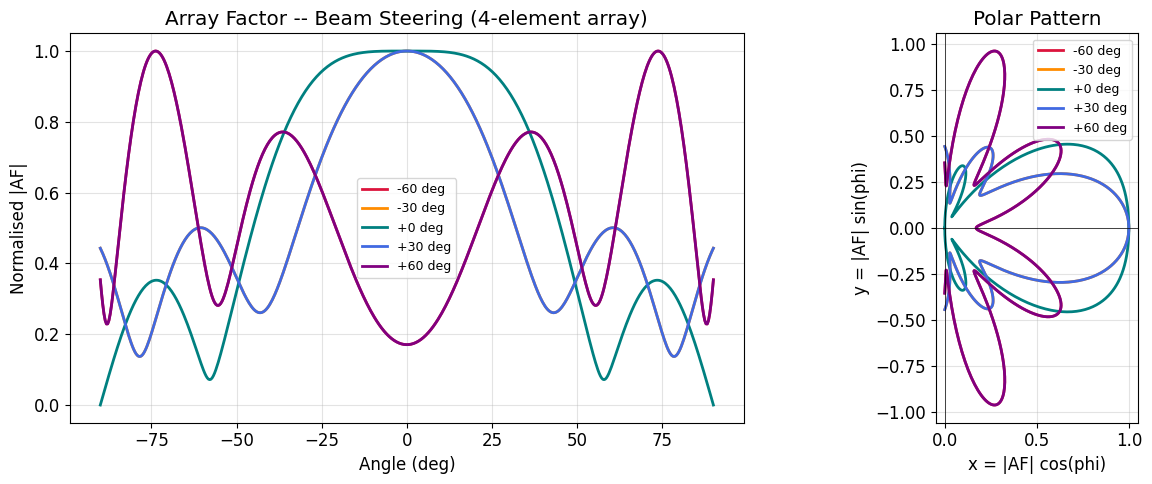

In [5]:
# Mutual impedances for 4-element half-wave dipole array
Z_self   =  73.1 + 42.5j
Z_adj    = -12.5 - 29.9j
Z_2d     =   4.0 + 17.9j
Z_3d     =  -2.5 - 12.8j

Z_imp = np.array([
    [Z_self, Z_adj,  Z_2d,  Z_3d ],
    [Z_adj,  Z_self, Z_adj, Z_2d ],
    [Z_2d,   Z_adj,  Z_self,Z_adj],
    [Z_3d,   Z_2d,   Z_adj, Z_self]
])

print('Impedance matrix Z (Ohm):')
print(np.round(Z_imp, 1))
print()

# LU decomposition of real-part and imaginary-part combined
# Work with the real 8x8 augmented system: [Re(Z) -Im(Z); Im(Z) Re(Z)] x = ...
# Simpler: use numpy for complex LU, implement using scipy-compatible approach
# We apply our real LU by splitting into real block system
n_el = 4
ZR, ZI = Z_imp.real, Z_imp.imag
Z_block = np.block([[ZR, -ZI], [ZI, ZR]])   # 8x8 real equivalent

L_z, U_z, P_z = lu_decompose(Z_block)
print(f'LU factorisation of 8x8 real equivalent: max|PA-LU| = {np.max(np.abs(P_z@Z_block - L_z@U_z)):.2e}')
print()

# Steering angles
lam = 1.0      # normalised wavelength
d   = 0.5      # element spacing in wavelengths
thetas_deg = [-60, -30, 0, 30, 60]
colors_a = ['crimson','darkorange','teal','royalblue','purple']

# Continuous array factor angles for pattern plot
phi = np.linspace(-np.pi/2, np.pi/2, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes

print('{:<15}  {:>20}  {:>20}'.format('Steering', 'I[0] (A)', 'I[1] (A)'))
print('-'*60)

for theta_d, col in zip(thetas_deg, colors_a):
    theta_r = np.radians(theta_d)
    psi = 2 * np.pi * d * np.cos(theta_r)   # progressive phase shift
    # Excitation voltages with progressive phase
    v = np.array([np.exp(1j*k*psi) for k in range(n_el)])
    vR, vI = v.real, v.imag
    rhs_block = np.concatenate([vR, vI])

    # Solve using stored LU -- O(n^2)
    sol_block = lu_solve(L_z, U_z, P_z, rhs_block)
    i_real = sol_block[:n_el]
    i_imag = sol_block[n_el:]
    I_curr = i_real + 1j * i_imag

    label = f'{theta_d:+d} deg'
    print('{:<15}  {:>20}  {:>20}'.format(label, str(np.round(I_curr[0],4)), str(np.round(I_curr[1],4))))

    # Array factor AF(phi) = sum_k I_k * exp(j k * 2pi*d*cos(phi))
    AF = np.zeros(len(phi), dtype=complex)
    for k in range(n_el):
        AF += I_curr[k] * np.exp(1j * k * 2 * np.pi * d * np.cos(phi))
    AF_norm = np.abs(AF) / (np.max(np.abs(AF)) + 1e-30)

    ax1.plot(np.degrees(phi), AF_norm, color=col, lw=2, label=label)
    # Polar plot data
    ax2.plot(AF_norm * np.cos(phi), AF_norm * np.sin(phi), color=col, lw=2, label=label)

ax1.set(xlabel='Angle (deg)', ylabel='Normalised |AF|',
        title='Array Factor -- Beam Steering (4-element array)')
ax1.legend(fontsize=9)

ax2.set(xlabel='x = |AF| cos(phi)', ylabel='y = |AF| sin(phi)',
        title='Polar Pattern')
ax2.set_aspect('equal')
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 3. Efficiency: LU vs Repeated Gaussian Elimination

For $k$ right-hand sides the total cost is:

| Strategy | Cost |
|----------|------|
| Repeated Gaussian elimination | $k \times \mathcal{O}(n^3/3)$ |
| LU once + $k$ substitutions | $\mathcal{O}(n^3/3) + k \times \mathcal{O}(n^2)$ |
| **Savings factor** | $\approx k / (1 + 3k/n)$ for large $k$ |

For $k = 50$ and $n = 100$ the LU approach is roughly **50× faster** after accounting for the
fixed factorisation cost. We verify this empirically below.


Efficiency comparison:


  n = 80,  k = 40 right-hand sides

  Repeated GE total time : 110.57 ms
  LU factorisation       : 2.88 ms  (one-time cost)
  LU solve x40 times      : 3.59 ms
  LU total               : 6.47 ms
  Speed-up factor        : 17.1x
  Max |X_ge - X_lu|      : 3.47e-17  (both give same answer)


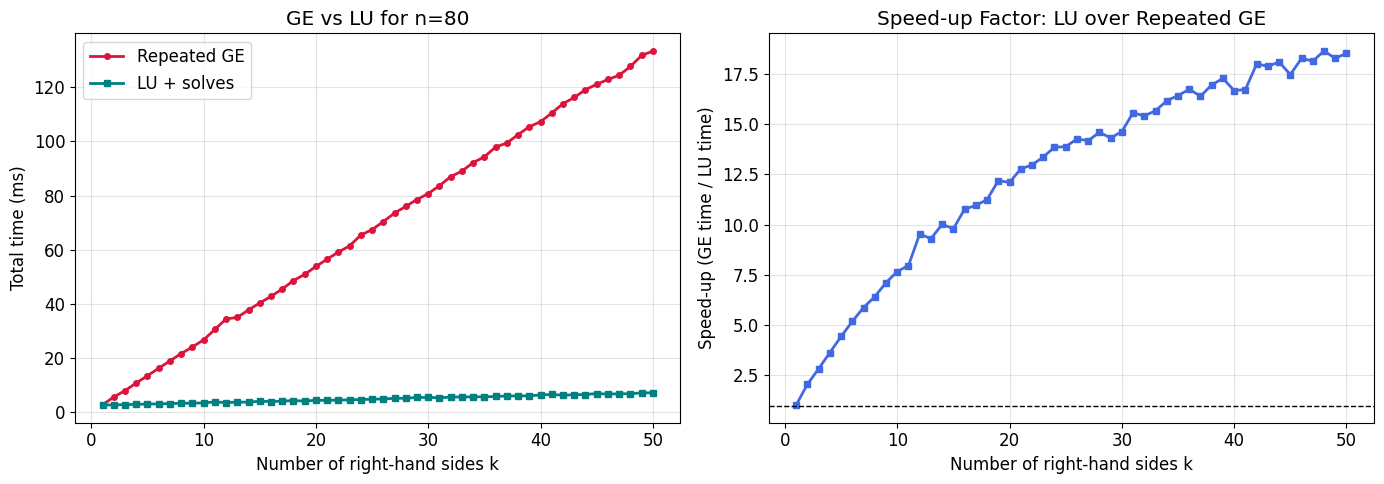

In [6]:
import time

# Import gaussian_elim from the previous notebook logic (inline here)
def gaussian_elim_local(A, b):
    n = len(b)
    M = np.hstack([np.array(A,dtype=float), np.array(b,dtype=float).reshape(-1,1)])
    for k in range(n-1):
        p = k + int(np.argmax(np.abs(M[k:, k])))
        if p != k: M[[k,p]] = M[[p,k]]
        for i in range(k+1, n):
            if abs(M[i,k]) < 1e-300: continue
            m = M[i,k]/M[k,k]; M[i,k:] -= m*M[k,k:]
    x = np.zeros(n)
    for i in range(n-1,-1,-1):
        x[i] = (M[i,-1] - M[i,i+1:n]@x[i+1:n]) / M[i,i]
    return x

rng  = np.random.default_rng(7)
n    = 80
k_rhs = 40
A_t  = rng.standard_normal((n, n)); A_t += n * np.eye(n)
B_t  = rng.standard_normal((n, k_rhs))

# Strategy 1: repeated Gaussian elimination
t0 = time.perf_counter()
X_ge = np.zeros((n, k_rhs))
for j in range(k_rhs):
    X_ge[:, j] = gaussian_elim_local(A_t, B_t[:, j])
t_ge = time.perf_counter() - t0

# Strategy 2: LU once + k solves
t0 = time.perf_counter()
L_t, U_t, P_t = lu_decompose(A_t)
t_fact = time.perf_counter() - t0
t0 = time.perf_counter()
X_lu = np.zeros((n, k_rhs))
for j in range(k_rhs):
    X_lu[:, j] = lu_solve(L_t, U_t, P_t, B_t[:, j])
t_lu_solves = time.perf_counter() - t0
t_lu_total  = t_fact + t_lu_solves

# Accuracy check
max_diff = np.max(np.abs(X_ge - X_lu))

print('Efficiency comparison:')
print(f'  n = {n},  k = {k_rhs} right-hand sides')
print()
print(f'  Repeated GE total time : {t_ge*1000:.2f} ms')
print(f'  LU factorisation       : {t_fact*1000:.2f} ms  (one-time cost)')
print(f'  LU solve x{k_rhs} times      : {t_lu_solves*1000:.2f} ms')
print(f'  LU total               : {t_lu_total*1000:.2f} ms')
print(f'  Speed-up factor        : {t_ge/t_lu_total:.1f}x')
print(f'  Max |X_ge - X_lu|      : {max_diff:.2e}  (both give same answer)')

# Plot: time vs number of RHS
k_vals = list(range(1, 51))
t_ge_k, t_lu_k = [], []
for kv in k_vals:
    t0 = time.perf_counter()
    for j in range(kv): gaussian_elim_local(A_t, B_t[:, j % k_rhs])
    t_ge_k.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    Lv, Uv, Pv = lu_decompose(A_t)
    for j in range(kv): lu_solve(Lv, Uv, Pv, B_t[:, j % k_rhs])
    t_lu_k.append(time.perf_counter() - t0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(k_vals, [t*1000 for t in t_ge_k], 'o-', color='crimson', ms=4, label='Repeated GE')
ax.plot(k_vals, [t*1000 for t in t_lu_k], 's-', color='teal',   ms=4, label='LU + solves')
ax.set(xlabel='Number of right-hand sides k', ylabel='Total time (ms)',
       title=f'GE vs LU for n={n}')
ax.legend()

ax = axes[1]
speedup = [tg/tl for tg, tl in zip(t_ge_k, t_lu_k)]
ax.plot(k_vals, speedup, 's-', color='royalblue', ms=4)
ax.axhline(1, color='k', ls='--', lw=1)
ax.set(xlabel='Number of right-hand sides k', ylabel='Speed-up (GE time / LU time)',
       title='Speed-up Factor: LU over Repeated GE')

plt.tight_layout()
plt.show()

---
## 4. Student Exercises

---

**Exercise 1 — Determinant and sign**
The determinant of $A$ can be computed from the LU factorisation as:

$$\det(A) = \text{sign}(P) \cdot \prod_{i=0}^{n-1} u_{ii}$$

where $\text{sign}(P) = (-1)^s$ and $s$ is the number of row swaps in $P$.
Implement `lu_det(A)` and test it on a $5 \times 5$ random matrix. Compare with `np.linalg.det`.

---

**Exercise 2 — Crout variant**
The **Crout** variant of LU decomposition uses a free lower triangular $L$ and a
*unit upper triangular* $U$ (ones on the diagonal of $U$). Derive the Crout recurrences
and implement `crout_decompose(A)`. Verify that it produces the same solution as Doolittle.

---

**Exercise 3 — Heat conduction refinement**
Refine the reactor wall discretisation to $n_\text{int} = 20$ interior nodes.
For a heat generation profile $q''(x) = q_0 \sin(\pi x / L)$ (non-uniform),
show how the right-hand side vector changes but the stiffness matrix (and its LU factors)
remain the same. Compare the temperature profile to the analytical solution
$T(x) = T_L + (T_R - T_L)x/L + \frac{q_0 L^2}{\pi^2 k}\sin(\pi x/L)$.

---

**Exercise 4 — 8-element phased array**
Extend the antenna example to $n = 8$ elements. Assemble the $8 \times 8$ mutual impedance
matrix (the pattern $Z_{ij}$ depends only on $|i-j|$). Compute beam patterns for
$\theta_0 \in \{-45°, 0°, 45°\}$ and compare the main-lobe width against the 4-element case.

---

**Exercise 5 — Rank-1 update (Sherman-Morrison)**
Suppose $A' = A + \mathbf{u}\mathbf{v}^T$ (a rank-1 perturbation). The
**Sherman-Morrison formula** gives:

$$A'^{-1} = A^{-1} - \frac{A^{-1}\mathbf{u}\,\mathbf{v}^T A^{-1}}{1 + \mathbf{v}^T A^{-1} \mathbf{u}}$$

Implement this using the stored LU factors of $A$ (to compute $A^{-1}\mathbf{u}$ cheaply),
and verify it is faster than a full re-factorisation for large $n$.


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers*
   (7th ed., pp. 258–285). McGraw-Hill Education.
   *Chapter 10 derives the Doolittle LU factorisation from first principles, proves the
   determinant formula $\det A = \prod u_{ii}$, and discusses the multiple-RHS motivation
   quantified in Section 3 of this notebook.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis*
   (10th ed., pp. 400–420). Cengage Learning.
   *Section 6.5 presents both Doolittle and Crout variants with rigorous operation counts,
   and Algorithm 6.4 gives the full LU pseudocode with partial pivoting that the
   implementation in Section 1.3 follows directly.*

3. **Golub, G. H., & Van Loan, C. F.** (2013). *Matrix Computations* (4th ed., pp. 152–180).
   Johns Hopkins University Press.
   *Section 3.5 analyses the backward stability of LU with partial pivoting (Theorem 3.5.1)
   and discusses updating strategies for rank-1 perturbations (Section 3.5.3), the basis for
   Exercise 5.*

4. **Incropera, F. P., DeWitt, D. P., Bergman, T. L., & Lavine, A. S.** (2017).
   *Fundamentals of Heat and Mass Transfer* (8th ed., pp. 153–170). Wiley.
   *Section 3.4 derives the 1D steady-state heat equation with internal generation used in
   Example 2.2, and Section 4.3 discusses finite-difference discretisation into the
   tridiagonal linear system solved here.*

5. **Balanis, C. A.** (2016). *Antenna Theory: Analysis and Design* (4th ed., pp. 465–512).
   Wiley.
   *Section 8.3 defines and tabulates mutual impedances between half-wave dipole elements
   as a function of separation distance (the values used in Example 2.3), and Section 8.4
   derives the impedance-matrix equation $Z\mathbf{i} = \mathbf{v}$ for phased arrays.*
